In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd

In [3]:
sentiment = pd.read_csv('fear_greed_index.csv')
trades = pd.read_csv('historical_data.csv')

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

In [5]:
print("Sentiment Dataset Shape:", sentiment.shape)
print("Trader Dataset Shape:", trades.shape)

print("\nSentiment Columns:")
print(sentiment.columns)

print("\nTrader Columns:")
print(trades.columns)

Sentiment Dataset Shape: (2644, 4)
Trader Dataset Shape: (211224, 16)

Sentiment Columns:
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

Trader Columns:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [6]:
print("Sentiment Missing Values:")
print(sentiment.isnull().sum())

print("\nTrader Missing Values:")
print(trades.isnull().sum())

print("\nSentiment Duplicates:", sentiment.duplicated().sum())
print("Trader Duplicates:", trades.duplicated().sum())

Sentiment Missing Values:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Trader Missing Values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Sentiment Duplicates: 0
Trader Duplicates: 0


In [9]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)
sentiment['Date'] = sentiment['date'].dt.date
trades['Date'] = trades['Timestamp IST'].dt.date


In [10]:
data = pd.merge(
    trades,
    sentiment[['Date','classification','value']],
    on='Date',
    how='left'
)

In [11]:
print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)

print("\nMissing Values")
print(data.isnull().sum())

print("\nDuplicate Rows:", data.duplicated().sum())

Sentiment Shape: (2644, 5)
Trades Shape: (211224, 17)

Missing Values
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
Date                0
classification      6
value               6
dtype: int64

Duplicate Rows: 0


In [12]:
daily_pnl = data.groupby(['Date','Account'])['Closed PnL'].sum().reset_index()

In [13]:
trades_per_day = data.groupby('Date').size().reset_index(name='trade_count')

In [14]:
avg_trade_size = data.groupby('Account')['Size USD'].mean()

In [15]:
direction_ratio = data['Direction'].value_counts(normalize=True)
print(direction_ratio)

Direction
Open Long                    0.236218
Close Long                   0.230457
Open Short                   0.188146
Close Short                  0.170497
Sell                         0.094222
Buy                          0.079139
Spot Dust Conversion         0.000672
Short > Long                 0.000331
Long > Short                 0.000270
Auto-Deleveraging            0.000038
Liquidated Isolated Short    0.000005
Settlement                   0.000005
Name: proportion, dtype: float64


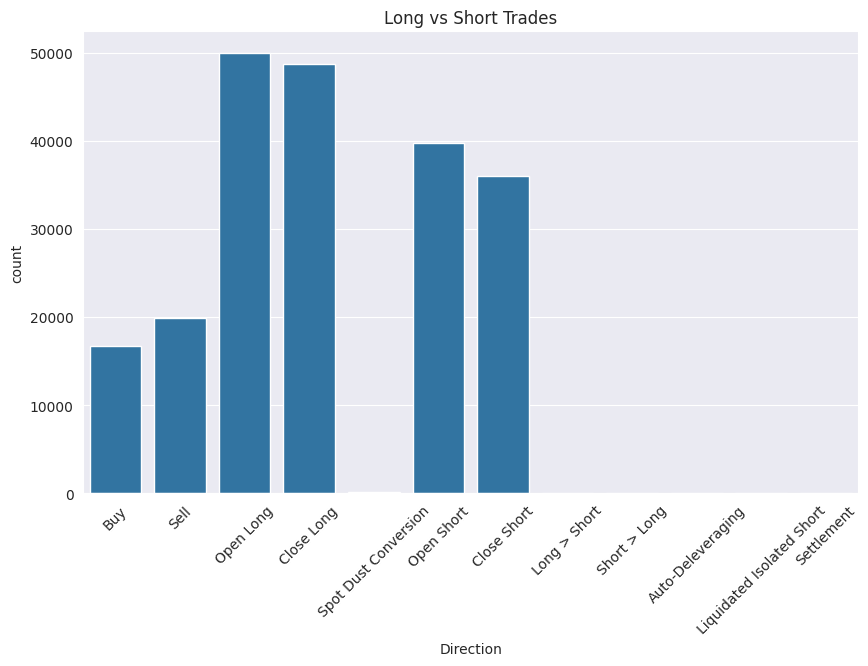

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.countplot(x='Direction', data=data)
plt.xticks(rotation=45)
plt.title("Long vs Short Trades")
plt.show()

In [21]:
data.groupby('classification')['Closed PnL'].mean()

,Closed PnL
classification,
Extreme Fear,34.537862
Extreme Greed,67.892861
Fear,54.290400
Greed,42.743559
Neutral,34.307718


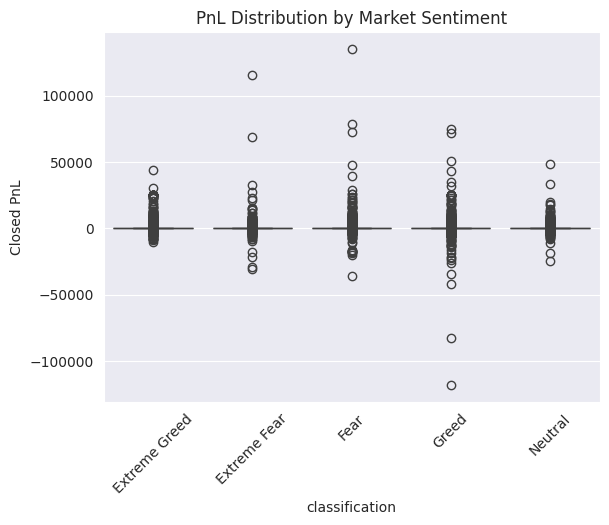

<Figure size 640x480 with 0 Axes>

In [60]:
sns.boxplot(x='classification', y='Closed PnL', data=data)
plt.title("PnL Distribution by Market Sentiment")
plt.xticks(rotation=45)
plt.show()

plt.savefig("sentiment_vs_profit.png")

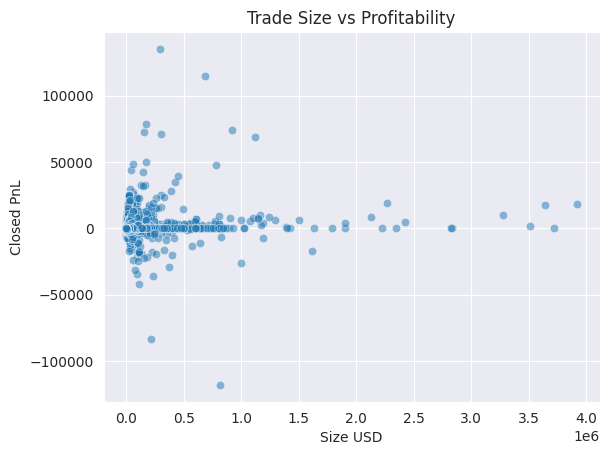

<Figure size 640x480 with 0 Axes>

In [63]:
sns.scatterplot(
    x=data['Size USD'],
    y=data['Closed PnL'],
    alpha=0.5
)
plt.title("Trade Size vs Profitability")
plt.show()

plt.savefig("trade_vs_profit.png")

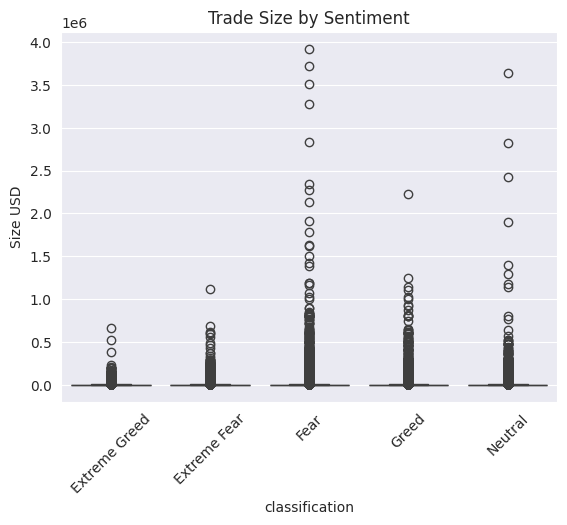

In [23]:
sns.boxplot(x='classification', y='Size USD', data=data)
plt.title("Trade Size by Sentiment")
plt.xticks(rotation=45)
plt.show()

In [25]:
median_size = data['Size USD'].median()

data['Trader_Type'] = data['Size USD'].apply(
    lambda x: 'High Volume' if x > median_size else 'Low Volume'
)

In [29]:
trade_counts = data['Account'].value_counts()

threshold = trade_counts.median()

data['Trader_Frequency'] = data['Account'].apply(
    lambda x: 'Frequent' if trade_counts[x] > threshold else 'Infrequent'
)
print(trade_counts)

Account
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    40184
0xbaaaf6571ab7d571043ff1e313a9609a10637864    21192
0xa0feb3725a9335f49874d7cd8eaad6be45b27416    15605
0x8477e447846c758f5a675856001ea72298fd9cb5    14998
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    14733
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    13311
0x513b8629fe877bb581bf244e326a047b249c4ff1    12236
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4     9893
0x47add9a56df66b524d5e2c1993a43cde53b6ed85     8519
0x4f93fead39b70a1824f981a54d4e55b278e9f760     7584
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     7280
0xb899e522b5715391ae1d4f137653e7906c5e2115     4838
0x8170715b3b381dffb7062c0298972d4727a0a63b     4601
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4     4356
0x083384f897ee0f19899168e3b1bec365f52a9012     3818
0x271b280974205ca63b716753467d5a371de622ab     3809
0x39cef799f8b69da1995852eea189df24eb5cae3c     3589
0x2c229d22b100a7beb69122eed721cee9b24011dd     3239
0x92f17e8d81a944691c10e753af1b1baae1a2cd0d     3052
0xbd

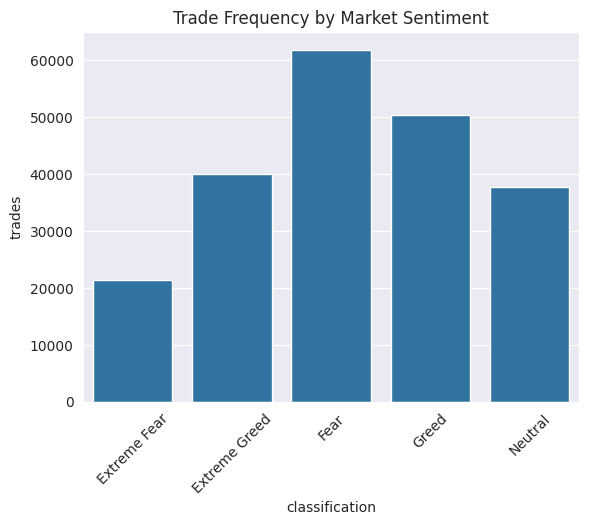

In [30]:
trades_sentiment = data.groupby('classification').size().reset_index(name='trades')

sns.barplot(x='classification', y='trades', data=trades_sentiment)
plt.title("Trade Frequency by Market Sentiment")
plt.xticks(rotation=45)
plt.show()

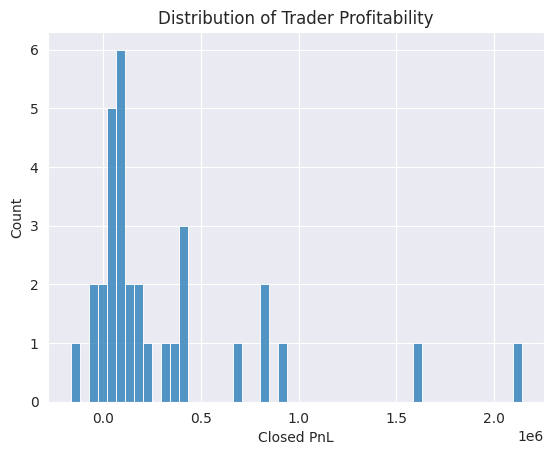

<Figure size 640x480 with 0 Axes>

In [57]:
trader_pnl = data.groupby('Account')['Closed PnL'].sum().reset_index()

sns.histplot(trader_pnl['Closed PnL'], bins=50)
plt.title("Distribution of Trader Profitability")
plt.show()

plt.savefig("profit_distribution.png")

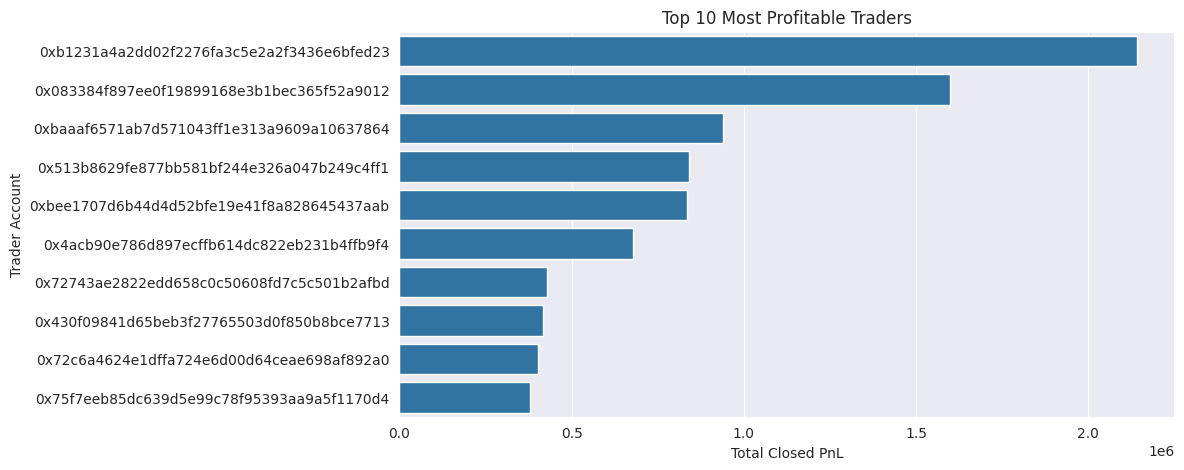

<Figure size 640x480 with 0 Axes>

In [66]:
top_traders = data.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_traders.values, y=top_traders.index)

plt.title("Top 10 Most Profitable Traders")
plt.xlabel("Total Closed PnL")
plt.ylabel("Trader Account")
plt.show()

plt.savefig("top_10_traders.png")

In [32]:
data['profit'] = (data['Closed PnL'] > 0).astype(int)

In [41]:
data['Direction'].unique()

array(['Buy', 'Sell', 'Open Long', 'Close Long', 'Spot Dust Conversion',
       'Open Short', 'Close Short', 'Long > Short', 'Short > Long',
       'Auto-Deleveraging', 'Liquidated Isolated Short', 'Settlement'],
      dtype=object)

In [42]:
def encode_direction(x):

    x = str(x)

    if 'Long' in x:
        return 1

    elif 'Short' in x:
        return -1

    else:
        return 0


data['Direction_encoded'] = data['Direction'].apply(encode_direction)

In [43]:
sentiment_map = {
    'Extreme Fear':0,
    'Fear':1,
    'Neutral':2,
    'Greed':3,
    'Extreme Greed':4
}

data['sentiment_encoded'] = data['classification'].map(sentiment_map)
numeric_data = data[[
    'Closed PnL',
    'Size USD',
    'Size Tokens',
    'Execution Price',
    'Fee',
    'Direction_encoded',
    'sentiment_encoded'
]]

In [44]:
corr_matrix = numeric_data.corr()

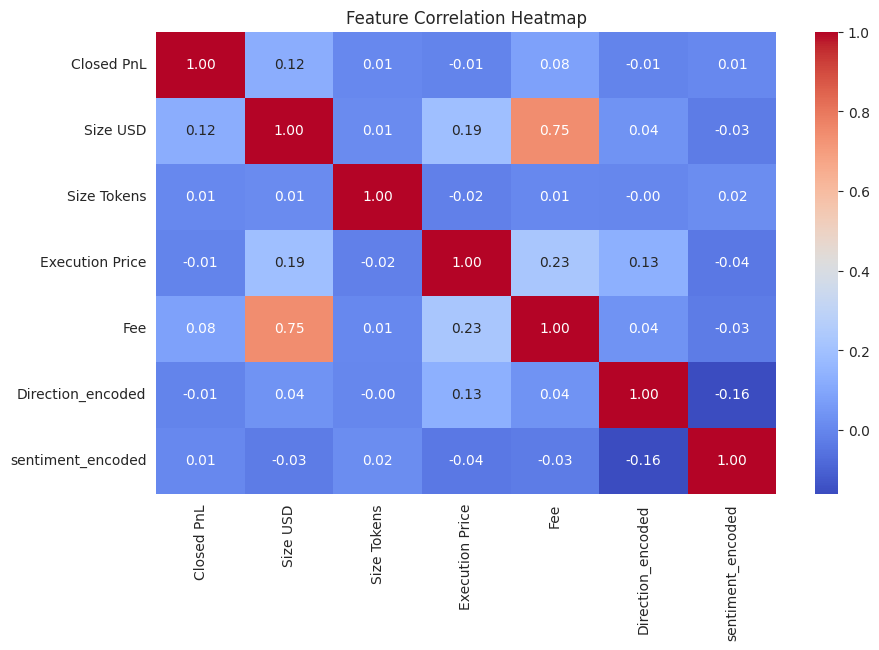

<Figure size 640x480 with 0 Axes>

In [68]:
plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

plt.savefig("correlation_heatmap.png")

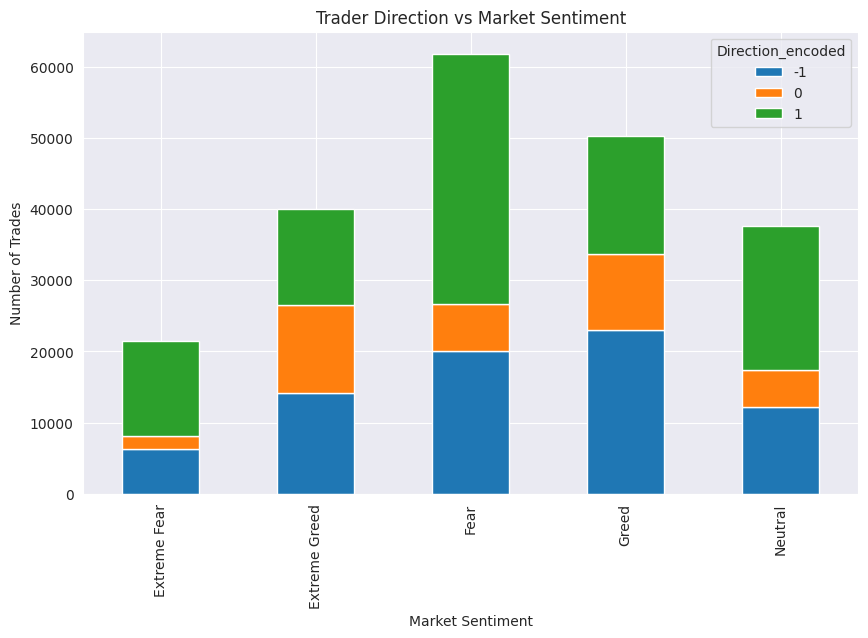

<Figure size 640x480 with 0 Axes>

In [65]:
pd.crosstab(data['classification'], data['Direction_encoded']).plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title("Trader Direction vs Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.show()

plt.savefig("trade_vs_sentiment.png")

In [47]:
profitability = data.groupby('Account')['Closed PnL'].sum()

profitable_traders = (profitability > 0).mean()

print("Percentage of profitable traders:", profitable_traders)

Percentage of profitable traders: 0.90625


In [50]:
features = data[
[
'Size USD',
'Fee',
'Execution Price',
'Direction_encoded',
'sentiment_encoded'
]]

target = data['profit']

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.88      0.91      0.89     24802
           1       0.86      0.82      0.84     17443

    accuracy                           0.87     42245
   macro avg       0.87      0.86      0.87     42245
weighted avg       0.87      0.87      0.87     42245



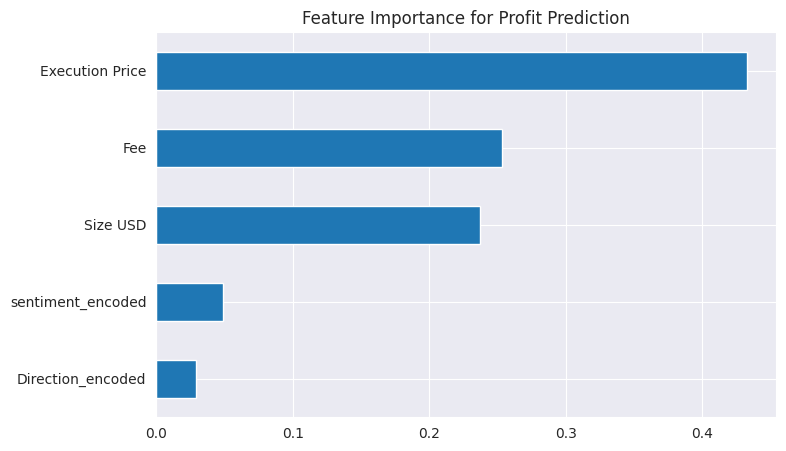

In [52]:
importance = pd.Series(model.feature_importances_, index=features.columns)

importance.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Feature Importance for Profit Prediction")
plt.show()

In [53]:
trader_features = data.groupby('Account').agg({
'Closed PnL':'sum',
'Size USD':'mean',
'Fee':'mean',
'Direction_encoded':'mean'
})

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(trader_features)

In [55]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(scaled_data)

trader_features['cluster'] = clusters

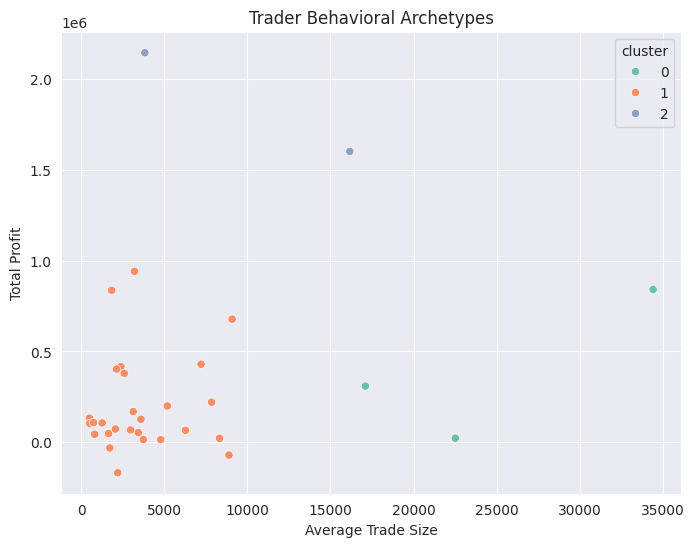

<Figure size 640x480 with 0 Axes>

In [69]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=trader_features['Size USD'],
    y=trader_features['Closed PnL'],
    hue=trader_features['cluster'],
    palette='Set2'
)

plt.title("Trader Behavioral Archetypes")
plt.xlabel("Average Trade Size")
plt.ylabel("Total Profit")
plt.show()

plt.savefig("cluster_plot.png")

### Cluster 0 - Small consistent traders          
### Cluster 1 - Large high-risk traders           
### Cluster 2 - High-frequency low-profit traders
